<a href="https://colab.research.google.com/github/AyushNegi785/bakanae-disease-detection/blob/main/inceptionet_aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (299, 299) # InceptionV3 specific size
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. Prepare File List and Labels ---
all_filepaths = []
all_labels = []

for label, folder_path in enumerate([PATH_BAKANAE, PATH_HEALTHY]): # 0: Bakanae, 1: Healthy
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [ ]:
def build_inception_model():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
    base_model.trainable = False

    model = models.Sequential([
        # Inception specific scaling (-1 to 1)
        layers.Lambda(tf.keras.applications.inception_v3.preprocess_input, input_shape=(299, 299, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# K-Fold Execution
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- InceptionV3: Training Fold {fold+1}/{NUM_FOLDS} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx]))
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx]))

    train_ds = train_ds.map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = val_ds.map(decode_img).batch(BATCH_SIZE)

    model = build_inception_model()
    model.fit(train_ds, epochs=10, verbose=0)

    # Prediction Probabilities
    y_true = all_labels[val_idx]
    y_probs = model.predict(val_ds).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Metrics for ROC
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)
    roc_curves.append((fpr, tpr, fold_auc))

    fold_results.append({
        'Fold': fold+1,
        'ACC': accuracy_score(y_true, y_pred),
        'PREC': precision_score(y_true, y_pred),
        'RECALL': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': fold_auc
    })
    all_cms.append(confusion_matrix(y_true, y_pred))

print("\nCross-Validation Training Complete.")


--- InceptionV3: Training Fold 1/5 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 67s 9s/step

--- InceptionV3: Training Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 8s/step

--- InceptionV3: Training Fold 3/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 65s 8s/step

--- InceptionV3: Training Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 8s/step

--- InceptionV3: Training Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 8s/step

Cross-Validation Training Complete.



--- Summary of InceptionV3 5-Fold Results ---
 Fold      ACC     PREC   RECALL       F1      AUC
    1 0.947368 0.900000 1.000000 0.947368 0.999174
    2 0.913876 0.893805 0.943925 0.918182 0.965915
    3 0.971154 0.989130 0.947917 0.968085 0.979260
    4 0.937500 0.912000 0.982759 0.946058 0.997095
    5 0.980769 0.982609 0.982609 0.982609 0.997382

--- Average Metrics ---
ACC       0.950133
PREC      0.935509
RECALL    0.971442
F1        0.952460
AUC       0.987765
dtype: float64


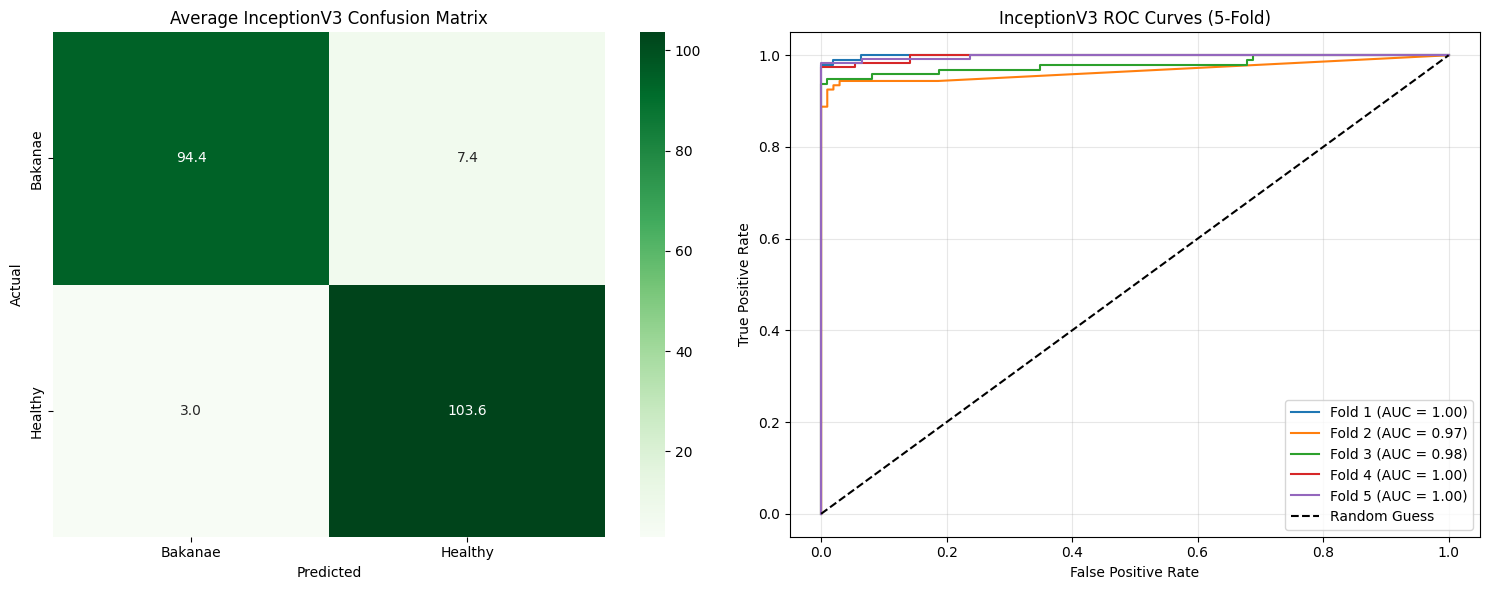

In [ ]:
# --- 1. Aggregate Results ---
results_df = pd.DataFrame(fold_results)
print("\n--- Summary of InceptionV3 5-Fold Results ---")
print(results_df.to_string(index=False))
print("\n--- Average Metrics ---")
print(results_df[['ACC', 'PREC', 'RECALL', 'F1', 'AUC']].mean())

# --- 2. Plotting ---
plt.figure(figsize=(15, 6))

# Subplot: Confusion Matrix
plt.subplot(1, 2, 1)
avg_cm = np.mean(all_cms, axis=0)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Average InceptionV3 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Subplot: ROC Curves
plt.subplot(1, 2, 2)
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('InceptionV3 ROC Curves (5-Fold)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

# InceptionV3 native input size is 299x299
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. Load Filepaths ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label


INCEPTION-V3: TRAINING FOLD 1/5
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 8s/step
Fold 1 Metrics -> Acc: 0.9761 | F1: 0.9754 | Recall: 1.0000


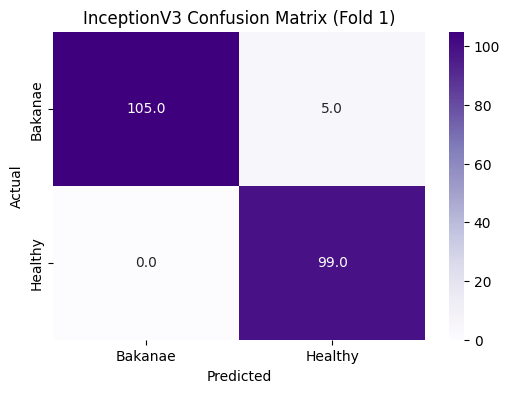


INCEPTION-V3: TRAINING FOLD 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 58s 7s/step
Fold 2 Metrics -> Acc: 0.9569 | F1: 0.9573 | Recall: 0.9439


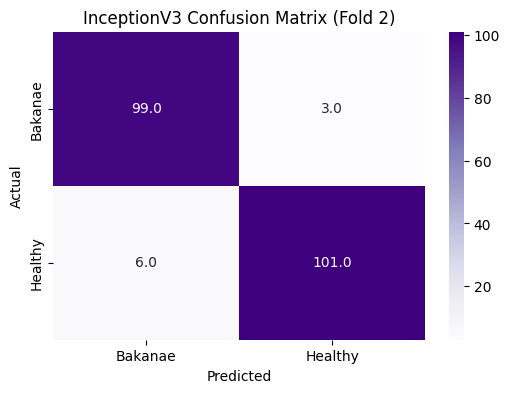


INCEPTION-V3: TRAINING FOLD 3/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 69s 9s/step
Fold 3 Metrics -> Acc: 0.9712 | F1: 0.9681 | Recall: 0.9479


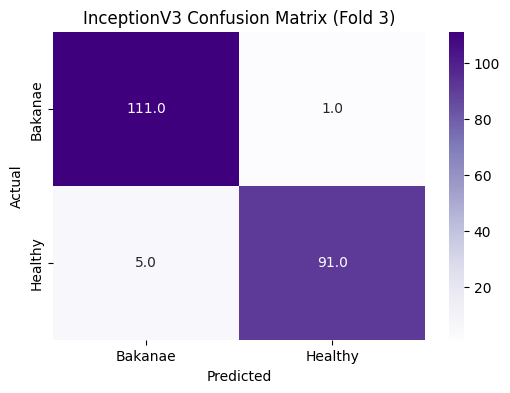


INCEPTION-V3: TRAINING FOLD 4/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 8s/step
Fold 4 Metrics -> Acc: 0.9712 | F1: 0.9744 | Recall: 0.9828


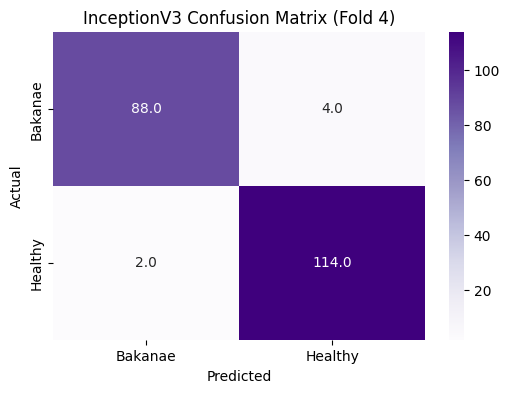


INCEPTION-V3: TRAINING FOLD 5/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 57s 7s/step
Fold 5 Metrics -> Acc: 0.9808 | F1: 0.9826 | Recall: 0.9826


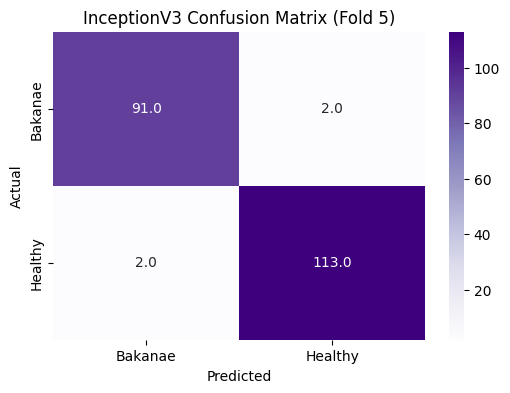


Cross-Validation Training Complete.


In [ ]:
def plot_cm_image(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Purples',
                xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def build_inception_model():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
    base_model.trainable = False

    model = models.Sequential([
        # InceptionV3 preprocessing scales pixels between -1 and 1
        layers.Lambda(tf.keras.applications.inception_v3.preprocess_input, input_shape=(299, 299, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n" + "="*35)
    print(f"INCEPTION-V3: TRAINING FOLD {fold+1}/{NUM_FOLDS}")
    print("="*35)

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx])).map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_inception_model()
    model.fit(train_ds, epochs=10, verbose=0)

    y_true = all_labels[val_idx]
    y_probs = model.predict(val_ds).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)

    # Storage
    roc_curves.append((fpr, tpr, fold_auc))
    all_cms.append(cm)
    fold_results.append({'ACC': acc, 'F1': f1, 'RECALL': rec, 'AUC': fold_auc})

    # Output
    print(f"Fold {fold+1} Metrics -> Acc: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")
    plot_cm_image(cm, f'InceptionV3 Confusion Matrix (Fold {fold+1})')

print("\nCross-Validation Training Complete.")

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. Load Filepaths ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

INCEPTION-V3 MODEL PARAMETERS


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)



--- FOLD 1 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 84s 10s/step
Train Time: 1822.66s | Test Time: 84.4201s
Metrics -> Acc: 0.9761 | F1: 0.9751 | Recall: 0.9899


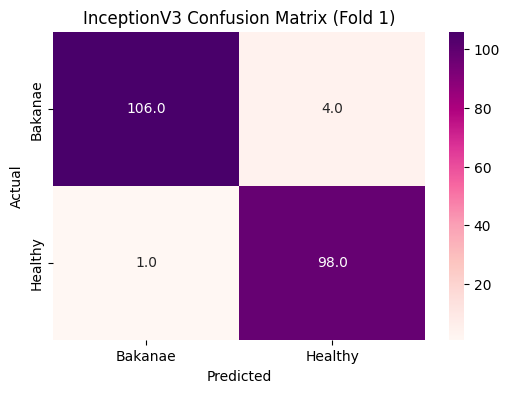


--- FOLD 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step
Train Time: 1747.20s | Test Time: 46.3311s
Metrics -> Acc: 0.9234 | F1: 0.9266 | Recall: 0.9439


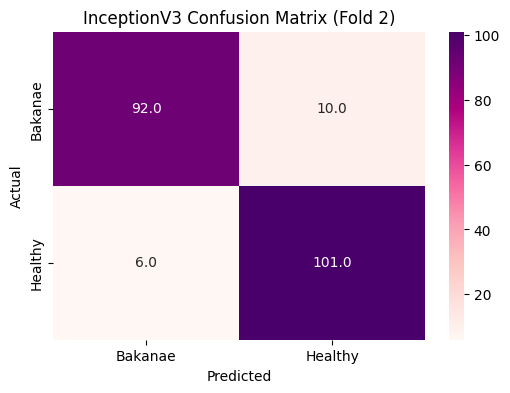


--- FOLD 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step
Train Time: 1724.77s | Test Time: 82.0309s
Metrics -> Acc: 0.9135 | F1: 0.9109 | Recall: 0.9583


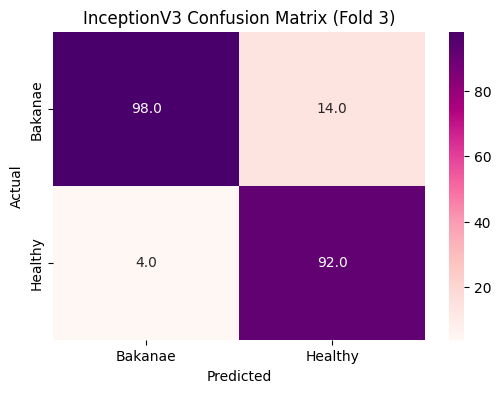


--- FOLD 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step
Train Time: 1813.73s | Test Time: 81.9393s
Metrics -> Acc: 0.9712 | F1: 0.9744 | Recall: 0.9828


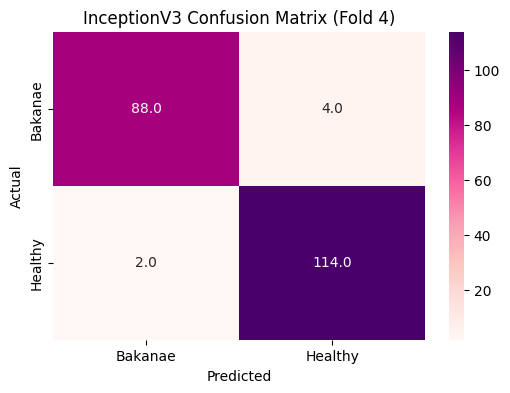


--- FOLD 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step
Train Time: 1799.72s | Test Time: 44.2143s
Metrics -> Acc: 0.9808 | F1: 0.9826 | Recall: 0.9826


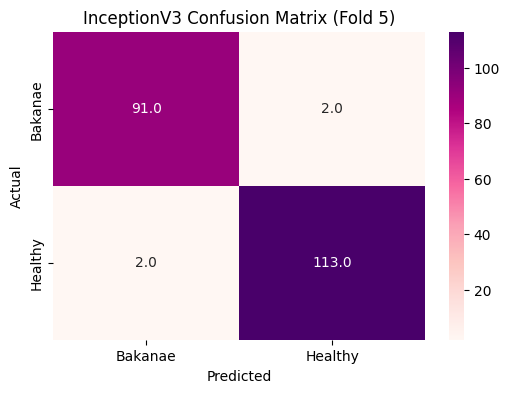

In [ ]:
def plot_cm_image(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='RdPu',
                xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def build_inception_model():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
    base_model.trainable = False
    model = models.Sequential([
        layers.Lambda(tf.keras.applications.inception_v3.preprocess_input, input_shape=(299, 299, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Show Model Parameters Once
temp_model = build_inception_model()
print("\n" + "="*50)
print("INCEPTION-V3 MODEL PARAMETERS")
temp_model.summary()
print("="*50 + "\n")

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- FOLD {fold+1} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx])).map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_inception_model()

    # 1. Measure Training Time
    start_train = time.time()
    model.fit(train_ds, epochs=10, verbose=0)
    end_train = time.time()
    train_duration = end_train - start_train

    # 2. Measure Inference (Testing) Time
    start_test = time.time()
    y_probs = model.predict(val_ds).ravel()
    end_test = time.time()
    test_duration = end_test - start_test

    y_true = all_labels[val_idx]
    y_pred = (y_probs > 0.5).astype(int)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)

    # Printing results with time
    print(f"Train Time: {train_duration:.2f}s | Test Time: {test_duration:.4f}s")
    print(f"Metrics -> Acc: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")
    plot_cm_image(cm, f'InceptionV3 Confusion Matrix (Fold {fold+1})')

    all_cms.append(cm)
    roc_curves.append((fpr, tpr, fold_auc))
    fold_results.append({'ACC': acc, 'F1': f1, 'RECALL': rec, 'AUC': fold_auc, 'TRAIN_T': train_duration, 'TEST_T': test_duration})


##################################################
FINAL GLOBAL PERFORMANCE SUMMARY (INCEPTION-V3)
##################################################
Avg Accuracy:      0.9530
Avg F1-Score:      0.9539
Avg Recall:        0.9715
Avg AUC-ROC:       0.9884
Avg Training Time: 1781.61 seconds
Avg Inference Time:67.7871 seconds per fold
##################################################


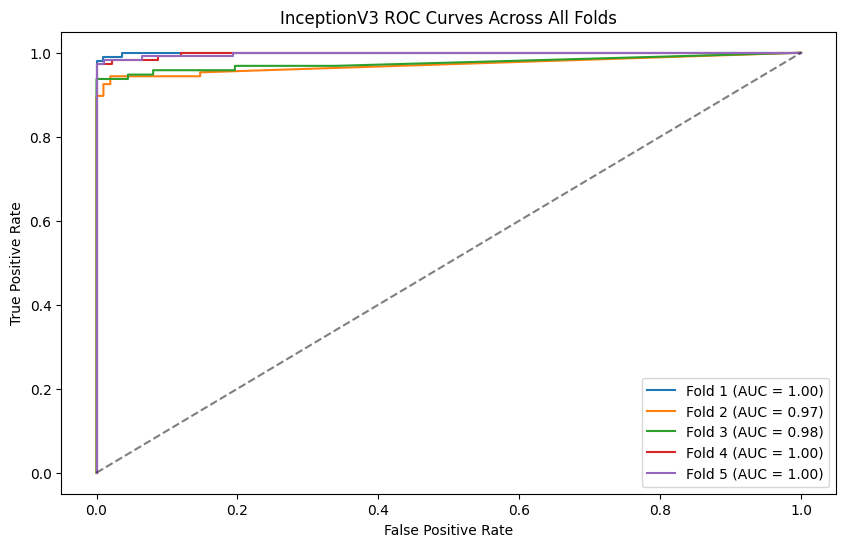

In [ ]:
results_df = pd.DataFrame(fold_results)
avg_cm = np.mean(all_cms, axis=0)

print("\n" + "#"*50)
print("FINAL GLOBAL PERFORMANCE SUMMARY (INCEPTION-V3)")
print("#"*50)
print(f"Avg Accuracy:      {results_df['ACC'].mean():.4f}")
print(f"Avg F1-Score:      {results_df['F1'].mean():.4f}")
print(f"Avg Recall:        {results_df['RECALL'].mean():.4f}")
print(f"Avg AUC-ROC:       {results_df['AUC'].mean():.4f}")
print(f"Avg Training Time: {results_df['TRAIN_T'].mean():.2f} seconds")
print(f"Avg Inference Time:{results_df['TEST_T'].mean():.4f} seconds per fold")
print("#"*50)

# Visualizing ROC
plt.figure(figsize=(10, 6))
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('InceptionV3 ROC Curves Across All Folds')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()